# Import librabries

In [2]:
import numpy as np
import pandas as pd
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [4]:
womens_world_cup_stats = pd.read_csv(
    '/Users/gui/womens_world_cup_2023_statsbomb_final.csv'
)

In [6]:
womens_world_cup_stats

,match_id,match_date,team,opponent,stage,goals_for,goals_against,result,points,possession_pct,...,goals_after_turnover,set_piece_goals,tackles,tackles_won,interceptions,blocks,clearances,recoveries,saves,clean_sheet
0,3893787,2023-07-20,New Zealand Women's,Norway Women's,Group,1,0,W,3,57.781529,...,0.0,1,27,13.0,8,28,24,72,2,1
1,3893787,2023-07-20,Norway Women's,New Zealand Women's,Group,0,1,L,0,42.218471,...,0.0,0,23,11.0,12,31,42,60,1,0
2,3893788,2023-07-20,Australia Women's,Republic of Ireland Women's,Group,1,0,W,3,58.013378,...,0.0,0,19,11.0,5,23,33,72,1,1
3,3893788,2023-07-20,Republic of Ireland Women's,Australia Women's,Group,0,1,L,0,41.986622,...,0.0,0,26,15.0,8,23,17,57,1,0
4,3893789,2023-07-21,Philippines Women's,Switzerland Women's,Group,0,2,L,0,30.212373,...,0.0,0,14,5.0,13,20,33,53,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,3904629,2023-08-16,England Women's,Australia Women's,Semi-finals,3,1,W,3,49.971523,...,1.0,1,19,12.0,7,16,30,51,3,0
124,3906389,2023-08-19,Australia Women's,Sweden Women's,Third-place,0,2,L,0,52.821967,...,0.0,0,18,11.0,17,27,9,66,3,0
125,3906389,2023-08-19,Sweden Women's,Australia Women's,Third-place,2,0,W,3,47.178033,...,1.0,0,26,16.0,12,31,29,65,4,1
126,3906390,2023-08-20,England Women's,Spain Women's,Final,0,1,L,0,44.284665,...,0.0,0,25,13.0,7,24,18,54,4,0


# Filter the Group Stage

In [9]:
group_stage = womens_world_cup_stats[
    womens_world_cup_stats['stage'] == 'Group'
]

In [11]:
group_stage

,match_id,match_date,team,opponent,stage,goals_for,goals_against,result,points,possession_pct,...,goals_after_turnover,set_piece_goals,tackles,tackles_won,interceptions,blocks,clearances,recoveries,saves,clean_sheet
0,3893787,2023-07-20,New Zealand Women's,Norway Women's,Group,1,0,W,3,57.781529,...,0.0,1,27,13.0,8,28,24,72,2,1
1,3893787,2023-07-20,Norway Women's,New Zealand Women's,Group,0,1,L,0,42.218471,...,0.0,0,23,11.0,12,31,42,60,1,0
2,3893788,2023-07-20,Australia Women's,Republic of Ireland Women's,Group,1,0,W,3,58.013378,...,0.0,0,19,11.0,5,23,33,72,1,1
3,3893788,2023-07-20,Republic of Ireland Women's,Australia Women's,Group,0,1,L,0,41.986622,...,0.0,0,26,15.0,8,23,17,57,1,0
4,3893789,2023-07-21,Philippines Women's,Switzerland Women's,Group,0,2,L,0,30.212373,...,0.0,0,14,5.0,13,20,33,53,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,3893832,2023-08-02,Jamaica Women's,Brazil Women's,Group,0,0,D,1,29.464669,...,0.0,0,22,12.0,13,30,46,67,8,1
92,3893833,2023-08-03,Germany Women's,Korea Republic Women's,Group,1,1,D,1,60.364924,...,0.0,0,16,10.0,14,14,32,64,1,0
93,3893833,2023-08-03,Korea Republic Women's,Germany Women's,Group,1,1,D,1,39.635076,...,0.0,0,25,12.0,10,28,26,64,2,0
94,3893834,2023-08-03,Colombia Women's,Morocco Women's,Group,0,1,L,0,58.744898,...,0.0,0,28,13.0,22,28,18,81,5,0


In [13]:
teams = womens_world_cup_stats["team"].unique()

list(teams)

["New Zealand Women's",
 "Norway Women's",
 "Australia Women's",
 "Republic of Ireland Women's",
 "Philippines Women's",
 "Switzerland Women's",
 "Canada Women's",
 "Nigeria Women's",
 "Costa Rica Women's",
 "Spain Women's",
 "United States Women's",
 "Vietnam Women's",
 "Japan Women's",
 'Zambia W',
 "England Women's",
 "Haiti Women's",
 "China PR Women's",
 "Denmark Women's",
 "South Africa Women's",
 "Sweden Women's",
 "Netherlands Women's",
 "Portugal Women's",
 "France Women's",
 "Jamaica Women's",
 "Germany Women's",
 "Morocco Women's",
 "Argentina Women's",
 "Italy Women's",
 "Brazil Women's",
 "Panama Women's",
 "Colombia Women's",
 "Korea Republic Women's"]

# Analysis Japan's Group Stage games

In [16]:
team = "Japan Women's"

games = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == team) |
        (womens_world_cup_stats["opponent"] == team)
    )
    &
    (womens_world_cup_stats["stage"] == "Group")
]

games[["match_id", "team", "opponent", "stage"]]

,match_id,team,opponent,stage
12,3893793,Japan Women's,Zambia W,Group
13,3893793,Zambia W,Japan Women's,Group
36,3893805,Costa Rica Women's,Japan Women's,Group
37,3893805,Japan Women's,Costa Rica Women's,Group
70,3893822,Japan Women's,Spain Women's,Group
71,3893822,Spain Women's,Japan Women's,Group


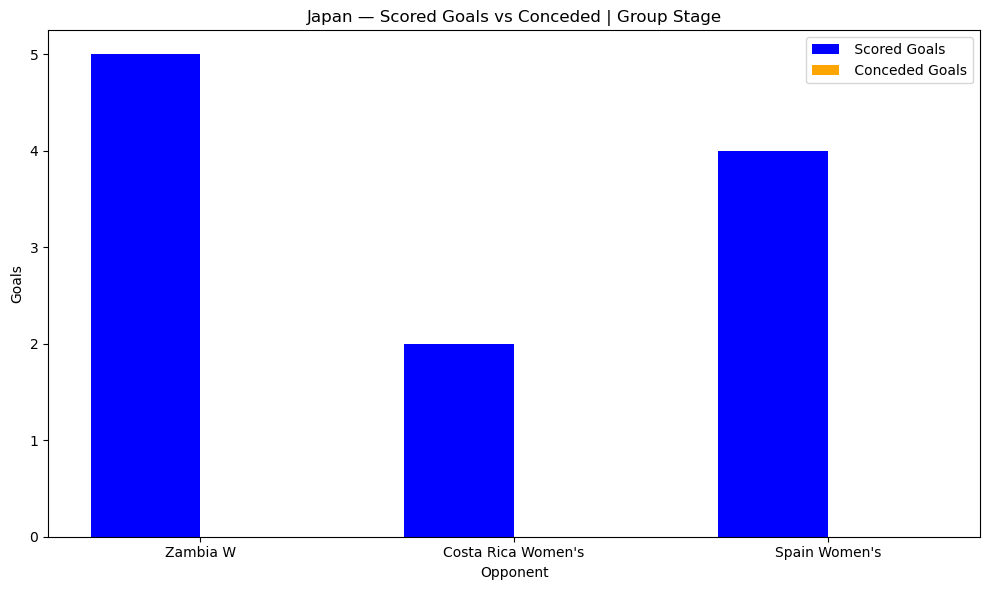

In [20]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Japan Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["goals_for"],
    width,
    label=" Scored Goals",
    color = "blue"
)

plt.bar(
    x + width / 2,
    group_games["goals_against"],
    width,
    label= " Conceded Goals",
    color = "orange"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Japan — Scored Goals vs Conceded | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

According to the chart above, Japan won all of its games, finishing with the highest point total in the group stage: 9 points.

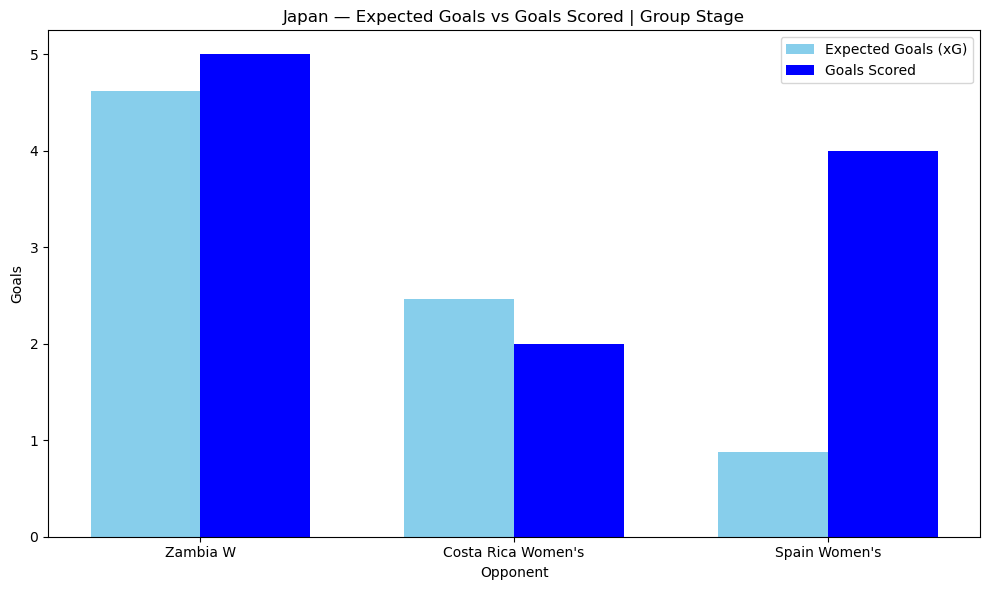

In [22]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Japan Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    group_games["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Japan — Expected Goals vs Goals Scored | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

Japan was always above the expectations, except for Costa Rica. The bigger discrepancy was the final result of the match against Spain.

# Analysis of JAP-SPA

In [28]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Japan Women's") &
        (womens_world_cup_stats["opponent"] == "Spain Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Spain Women's") &
        (womens_world_cup_stats["opponent"] == "Japan Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "Japan": [
        match.loc[
            match["team"] == "Japan Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Spain": [
        match.loc[
            match["team"] == "Spain Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Japan", "Spain"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Japan", "Spain"]
].round(1)


# Display table

comparison

,Metric,Japan,Spain
0,Goals,4.0,0.0
1,xG,0.9,0.6
2,Goals Minus xG,3.1,-0.6
3,Shots,7.0,10.0
4,Shots on Target,4.0,2.0
5,Saves,2.0,0.0
6,Possession %,31.3,68.7
7,Pass Accuracy %,63.1,88.3
8,Progressive Passes,79.0,175.0
9,Progressive Carries,9.0,43.0


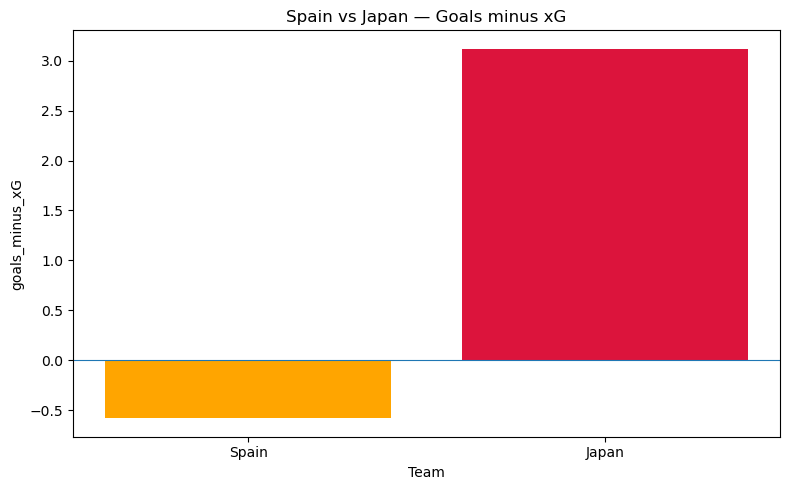

In [38]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Japan Women's") &
        (womens_world_cup_stats["opponent"] == "Spain Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Spain Women's") &
        (womens_world_cup_stats["opponent"] == "Japan Women's")
    )
].copy()



teams = ["Spain", "Japan"]

goals_minus_xG = [
    match.loc[match["team"] == "Spain Women's", "goals_minus_xG"].iloc[0],
    match.loc[match["team"] == "Japan Women's", "goals_minus_xG"].iloc[0]
]

plt.figure(figsize=(8, 5))

plt.bar(
    teams,
    goals_minus_xG,
    color=["orange", "crimson"]
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Team")
plt.ylabel("goals_minus_xG")
plt.title("Spain vs Japan — Goals minus xG")

plt.tight_layout()
plt.show()

Spain fell short of its xG, while Japan was well above it. These statistics point to a lack of efficiency on the part of the Spanish team.

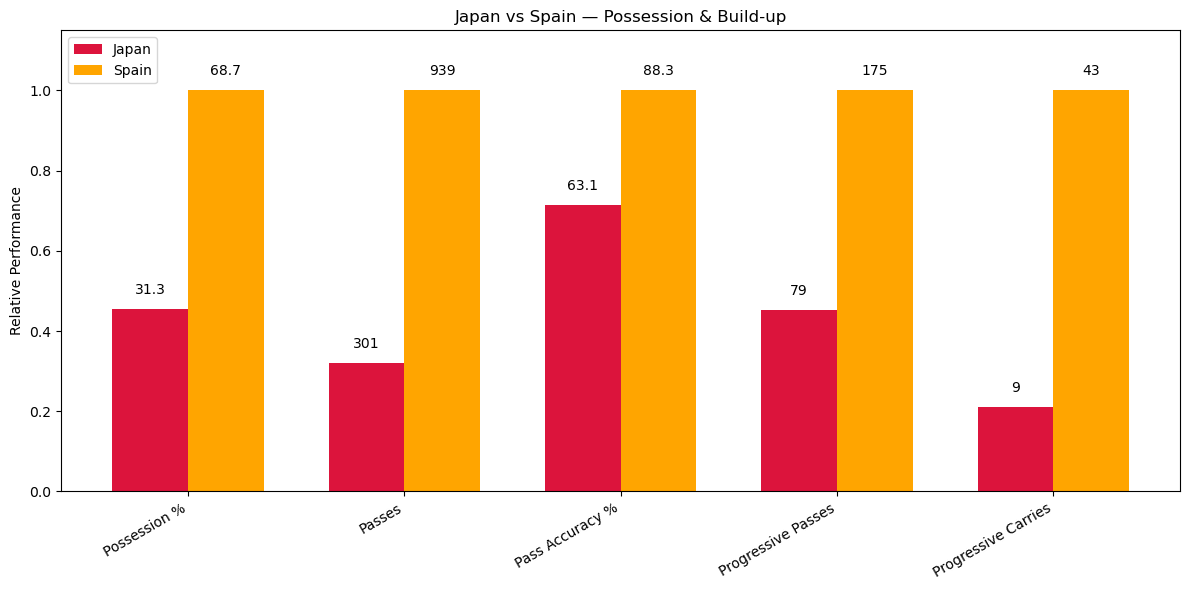

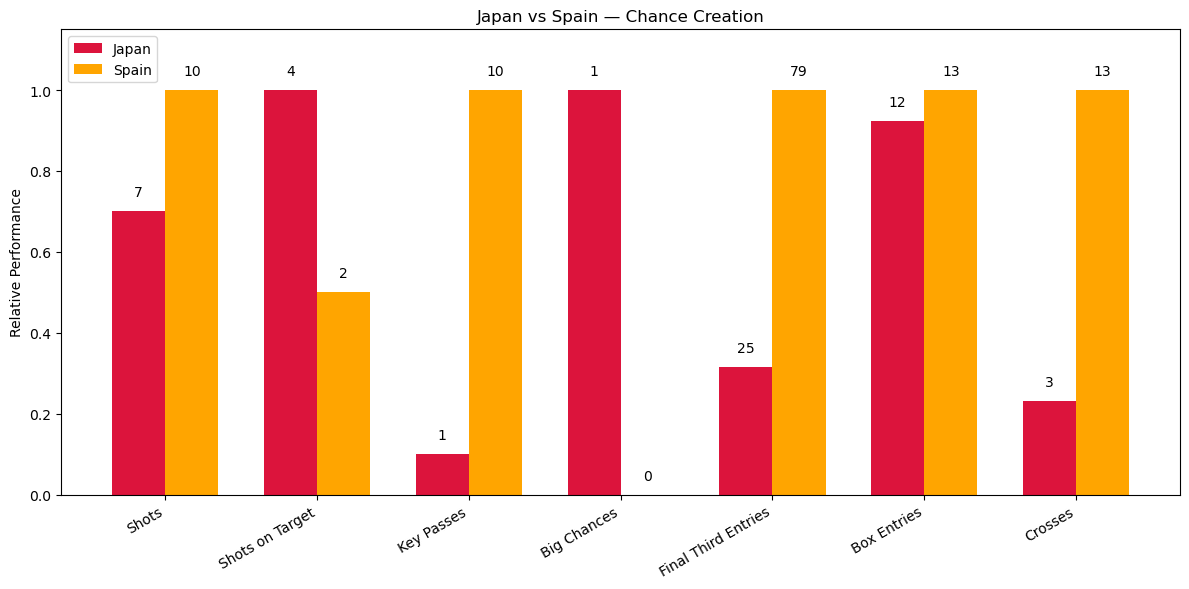

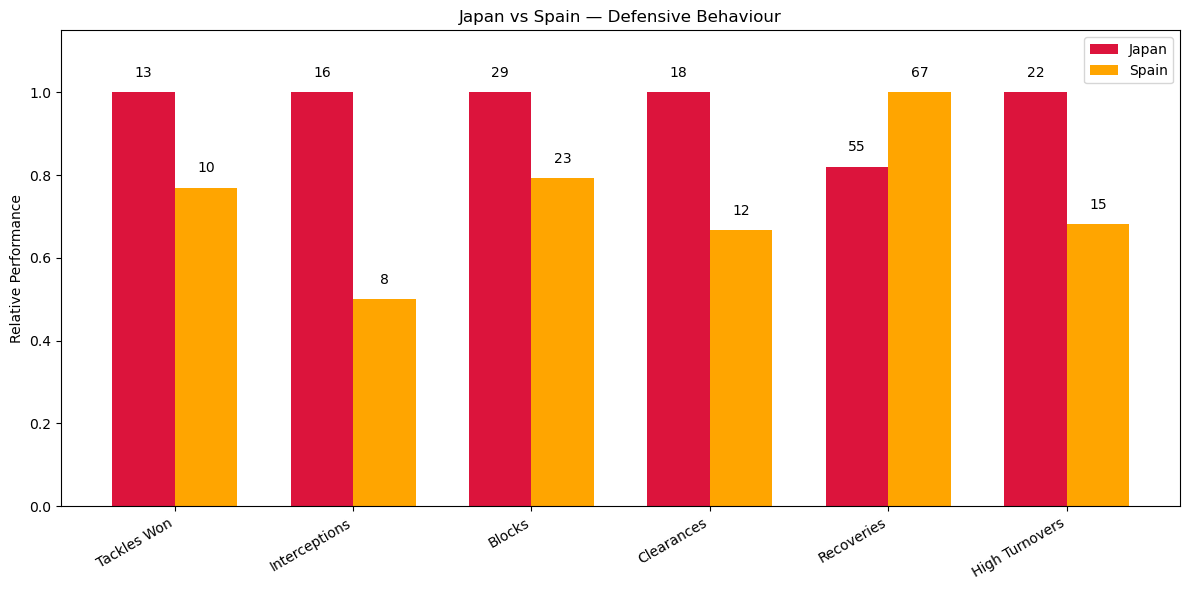

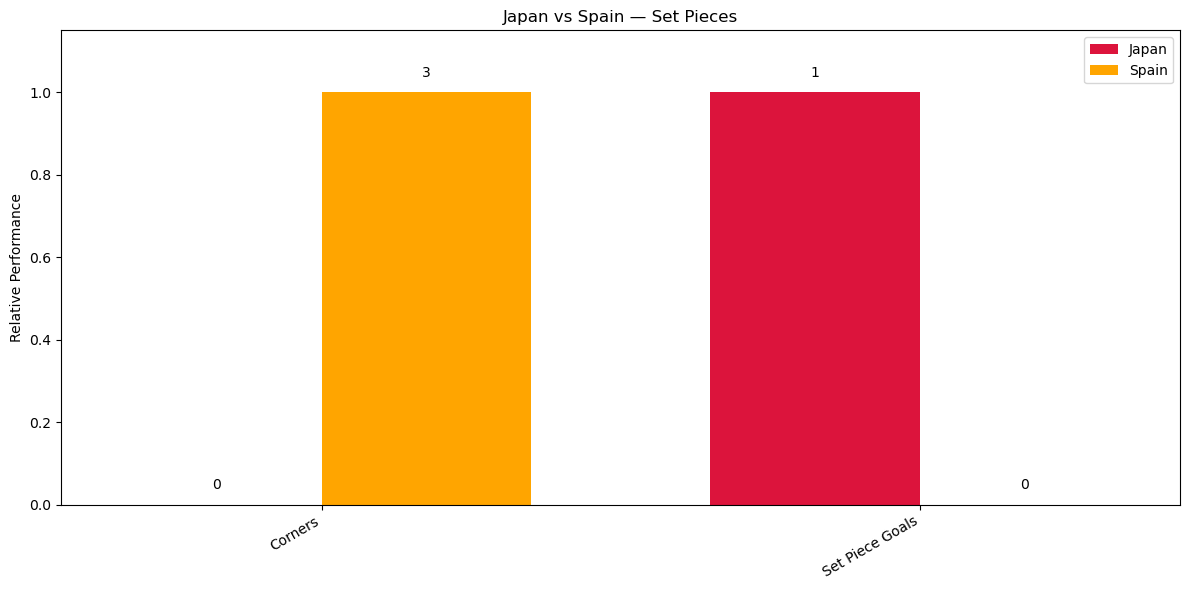

In [42]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Japan Women's") &
        (womens_world_cup_stats["opponent"] == "Spain Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Spain Women's") &
        (womens_world_cup_stats["opponent"] == "Japan Women's")
    )
].copy()

# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses"
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "Japan": "Japan Women's",
    "Spain": "Spain Women's"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    jap_values = np.array([
        match.loc[
            match["team"] == team_names["Japan"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    spa_values = np.array([
        match.loc[
            match["team"] == team_names["Spain"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(jap_values, spa_values)

    # Normalize
    jap_normalized = np.divide(
        jap_values,
        max_values,
        out=np.zeros_like(jap_values),
        where=max_values != 0
    )

    spa_normalized = np.divide(
        spa_values,
        max_values,
        out=np.zeros_like(spa_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_jap = plt.bar(
        x - width / 2,
        jap_normalized,
        width,
        label="Japan",
        color="crimson"
    )

    bars_spa = plt.bar(
        x + width / 2,
        spa_normalized,
        width,
        label="Spain",
        color="orange"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_jap, jap_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_spa, spa_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"Japan vs Spain — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

## Conclusion of JAP-SPA

Looking at the charts above, it appears that Spain dominated Japan throughout the 90 minutes of this match. However, despite the discrepancy in the numbers, Japan was extremely efficient. 
With just 7 shots, 4 of them were on target and resulted in a goal.
Looking at the *Defensive Behaviour* chart, Japan has higher values, indicating that the team adopted a more defensive strategy.

# Analysis of JAP-ZAM

In [50]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Japan Women's") &
        (womens_world_cup_stats["opponent"] == "Zambia W")
    ) |
    (
        (womens_world_cup_stats["team"] == "Zambia W") &
        (womens_world_cup_stats["opponent"] == "Japan Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "Japan": [
        match.loc[
            match["team"] == "Japan Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Zambia": [
        match.loc[
            match["team"] == "Zambia W", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Japan", "Zambia"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Japan", "Zambia"]
].round(1)


# Display table

comparison

,Metric,Japan,Zambia
0,Goals,5.0,0.0
1,xG,4.6,0.0
2,Goals Minus xG,0.4,0.0
3,Shots,26.0,0.0
4,Shots on Target,10.0,0.0
5,Saves,0.0,5.0
6,Possession %,67.9,32.1
7,Pass Accuracy %,79.4,68.6
8,Progressive Passes,194.0,130.0
9,Progressive Carries,32.0,15.0


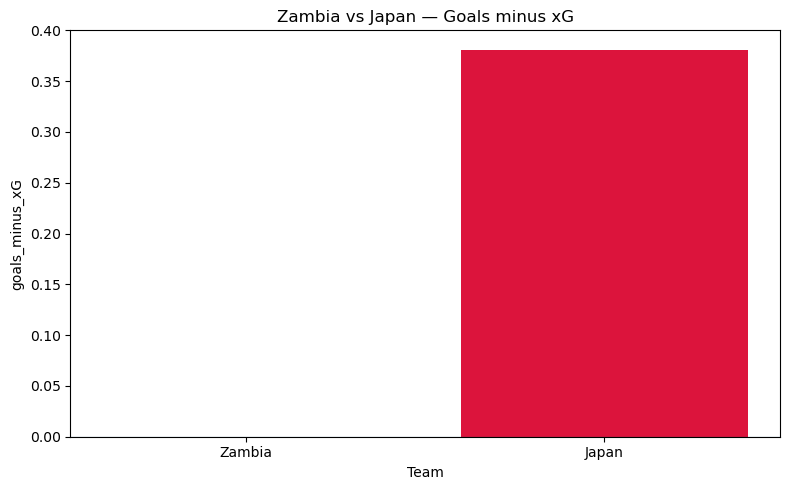

In [52]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Japan Women's") &
        (womens_world_cup_stats["opponent"] == "Zambia W")
    ) |
    (
        (womens_world_cup_stats["team"] == "Zambia W") &
        (womens_world_cup_stats["opponent"] == "Japan Women's")
    )
].copy()



teams = ["Zambia", "Japan"]

goals_minus_xG = [
    match.loc[match["team"] == "Zambia W", "goals_minus_xG"].iloc[0],
    match.loc[match["team"] == "Japan Women's", "goals_minus_xG"].iloc[0]
]

plt.figure(figsize=(8, 5))

plt.bar(
    teams,
    goals_minus_xG,
    color=["black", "crimson"]
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Team")
plt.ylabel("goals_minus_xG")
plt.title("Zambia vs Japan — Goals minus xG")

plt.tight_layout()
plt.show()

Zambia lived up to the xG prediction (0 goals), but Japan slightly exceeded that prediction, posting a better outcome.

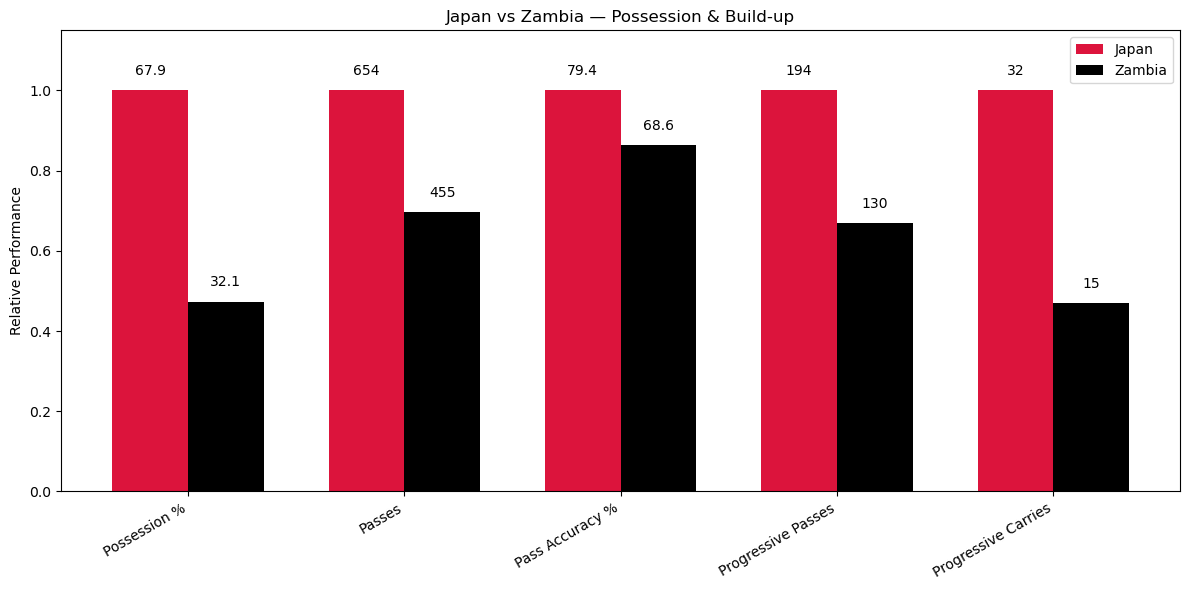

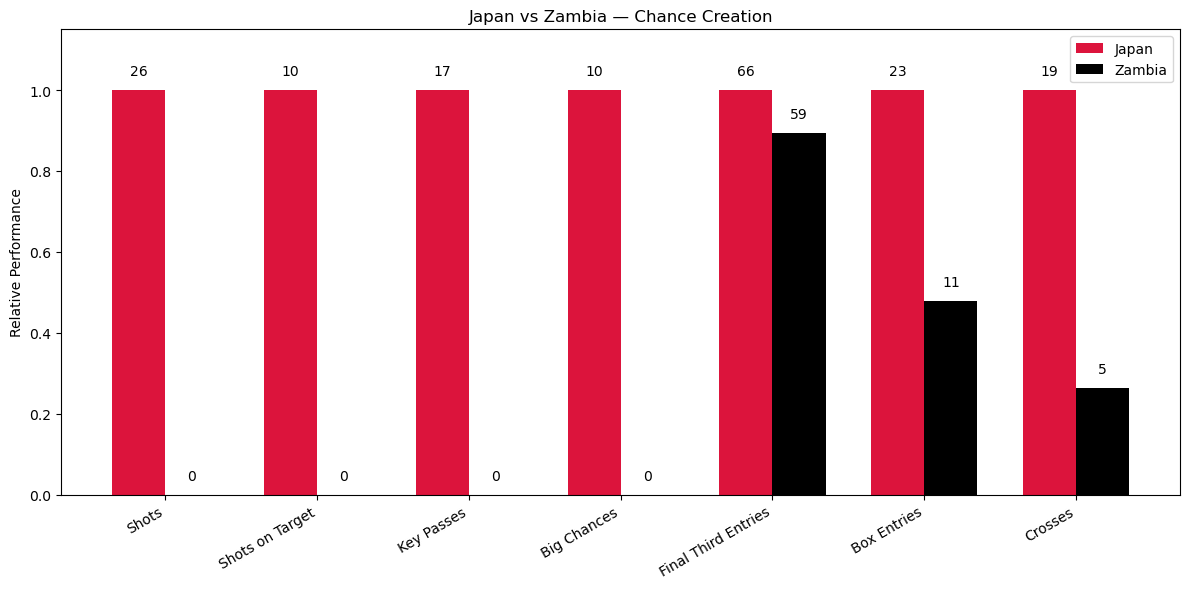

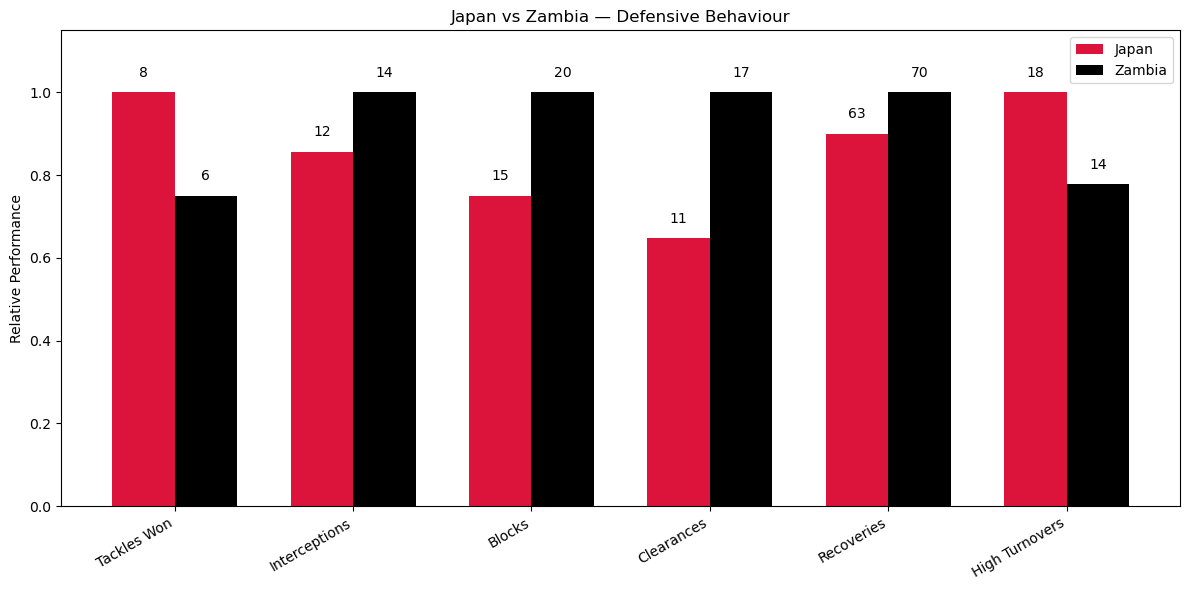

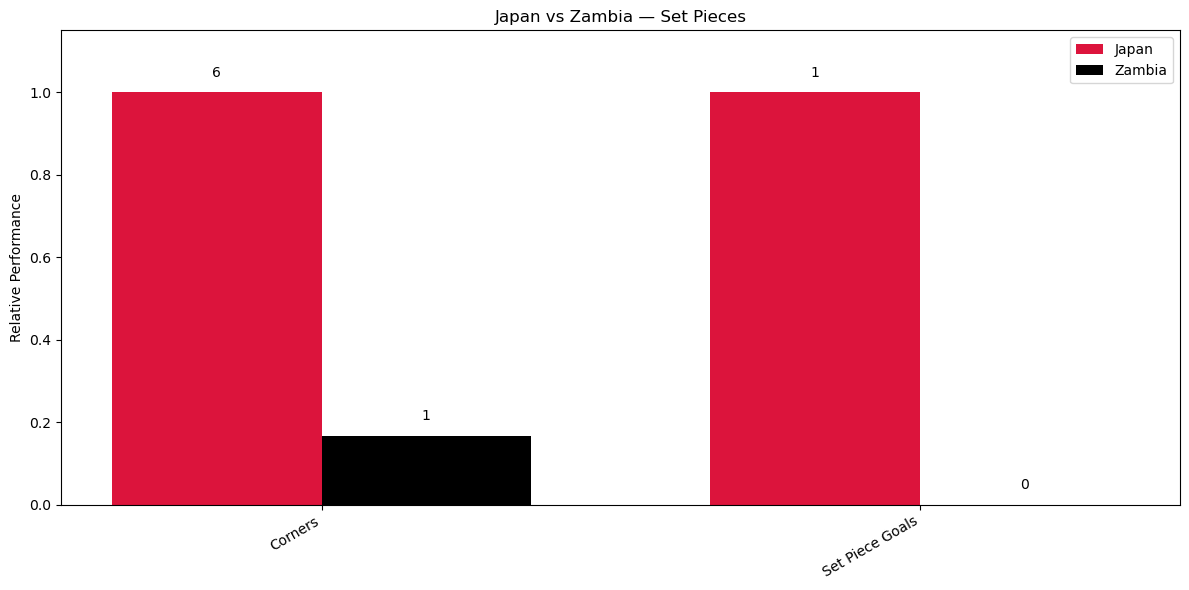

In [57]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Japan Women's") &
        (womens_world_cup_stats["opponent"] == "Zambia W")
    ) |
    (
        (womens_world_cup_stats["team"] == "Zambia W") &
        (womens_world_cup_stats["opponent"] == "Japan Women's")
    )
].copy()

# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses"
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "Japan": "Japan Women's",
    "Zambia": "Zambia W"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    jap_values = np.array([
        match.loc[
            match["team"] == team_names["Japan"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    zam_values = np.array([
        match.loc[
            match["team"] == team_names["Zambia"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(jap_values, zam_values)

    # Normalize
    jap_normalized = np.divide(
        jap_values,
        max_values,
        out=np.zeros_like(jap_values),
        where=max_values != 0
    )

    zam_normalized = np.divide(
        zam_values,
        max_values,
        out=np.zeros_like(zam_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_jap = plt.bar(
        x - width / 2,
        jap_normalized,
        width,
        label="Japan",
        color="crimson"
    )

    bars_zam = plt.bar(
        x + width / 2,
        zam_normalized,
        width,
        label="Zambia",
        color="black"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_jap, jap_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_zam, zam_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"Japan vs Zambia — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

## Conclusion JAP - ZAM 

Japan dominated the entire game. The statistics show significant disparities, especially on offense, such as:
<br>
- shots: 26–0
- shots on target: 10–0
- key passes: 17–0
- big chances: 10–0 <br>
<br>

Much of the game took place in Zambia’s defensive third—Japan’s attacking zone—and the African team adopted a defensive strategy. It’s also clear that they tried to make the most of what they had, having made 5 saves, 20 blocks, and 17 clearances. 

# Analysis of JAP-CRC

In [68]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Japan Women's") &
        (womens_world_cup_stats["opponent"] == "Costa Rica Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Costa Rica Women's") &
        (womens_world_cup_stats["opponent"] == "Japan Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "Japan": [
        match.loc[
            match["team"] == "Japan Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Costa Rica": [
        match.loc[
            match["team"] == "Costa Rica Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Japan", "Costa Rica"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Japan", "Costa Rica"]
].round(1)


# Display table

comparison

,Metric,Japan,Costa Rica
0,Goals,2.0,0.0
1,xG,2.5,0.1
2,Goals Minus xG,-0.5,-0.1
3,Shots,23.0,6.0
4,Shots on Target,11.0,1.0
5,Saves,2.0,9.0
6,Possession %,63.0,37.0
7,Pass Accuracy %,80.6,76.8
8,Progressive Passes,145.0,117.0
9,Progressive Carries,19.0,15.0


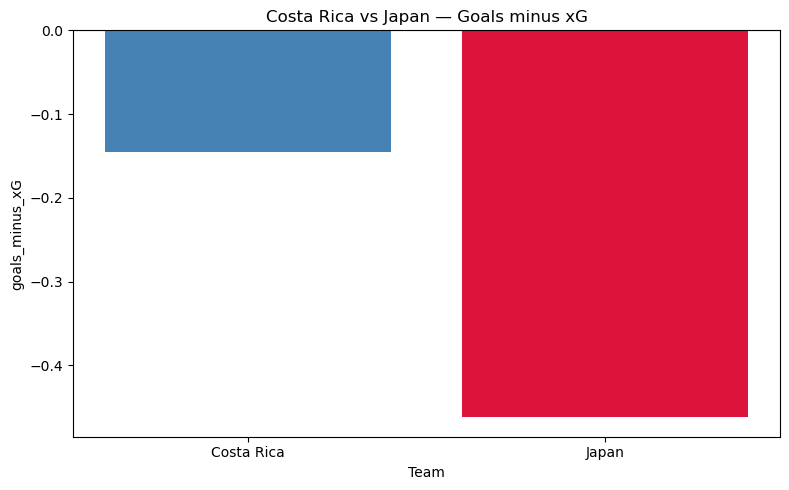

In [70]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Japan Women's") &
        (womens_world_cup_stats["opponent"] == "Costa Rica Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Costa Rica Women's") &
        (womens_world_cup_stats["opponent"] == "Japan Women's")
    )
].copy()



teams = ["Costa Rica", "Japan"]

goals_minus_xG = [
    match.loc[match["team"] == "Costa Rica Women's", "goals_minus_xG"].iloc[0],
    match.loc[match["team"] == "Japan Women's", "goals_minus_xG"].iloc[0]
]

plt.figure(figsize=(8, 5))

plt.bar(
    teams,
    goals_minus_xG,
    color=["steelblue", "crimson"]
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Team")
plt.ylabel("goals_minus_xG")
plt.title("Costa Rica vs Japan — Goals minus xG")

plt.tight_layout()
plt.show()

Both teams fell short of expectations. Japan scored 2 goals and had an xG of 2.5, while Costa Rica did not score any goals and had an xG of 0.1.

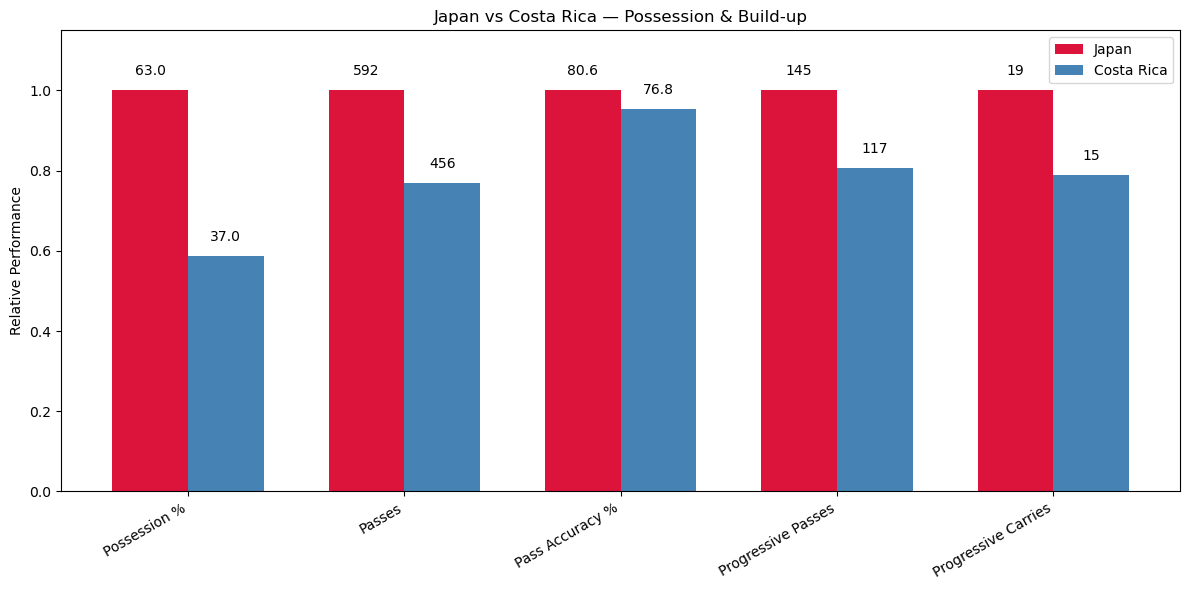

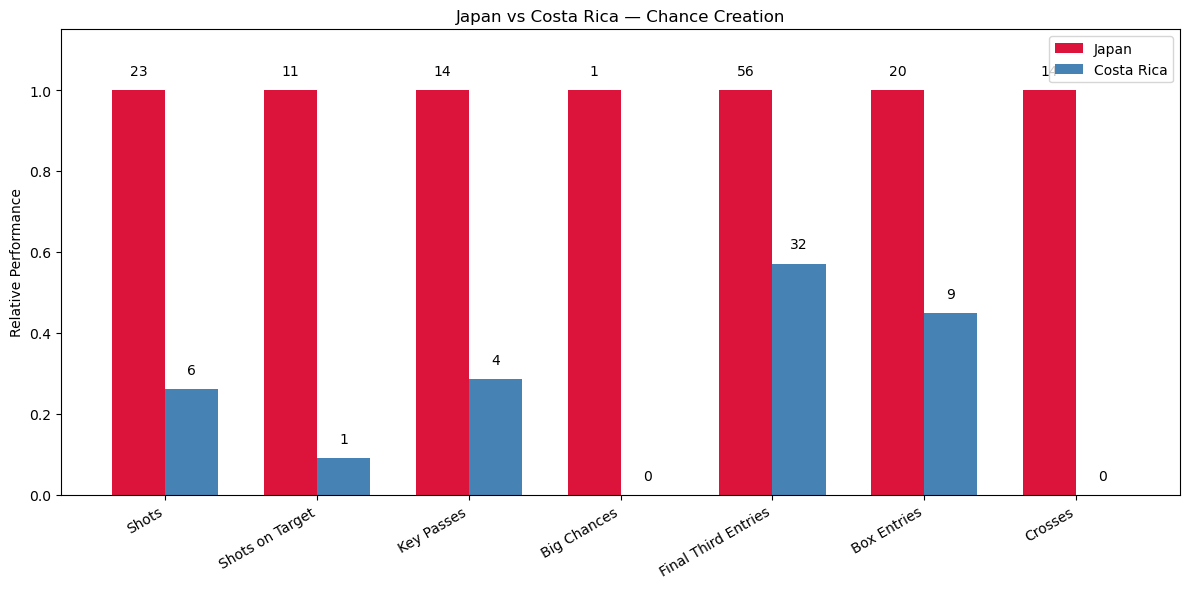

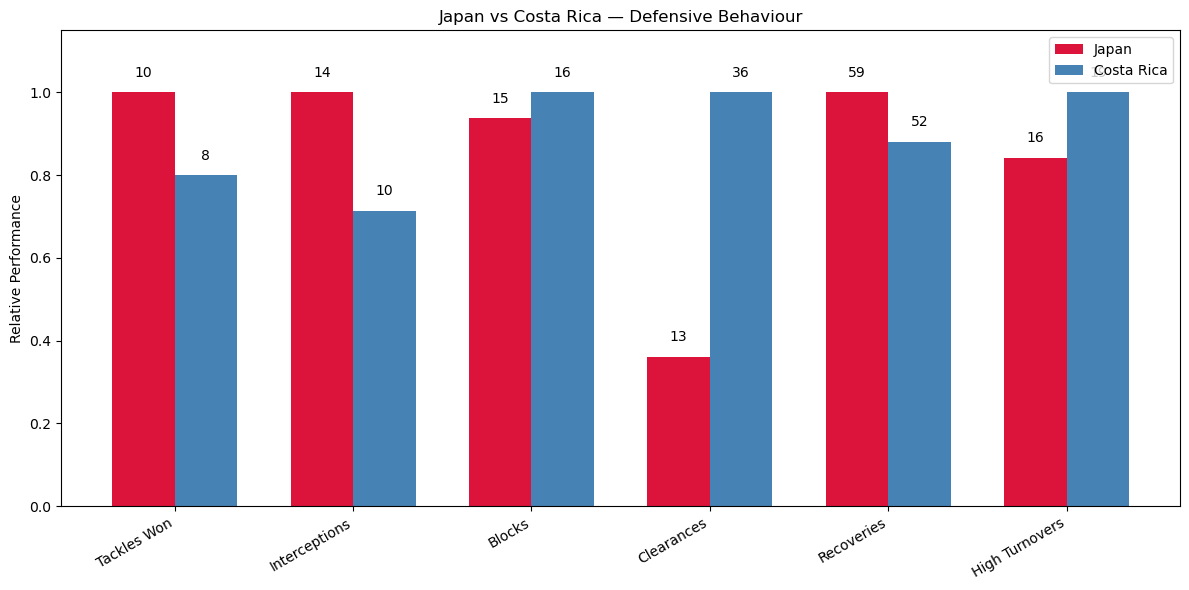

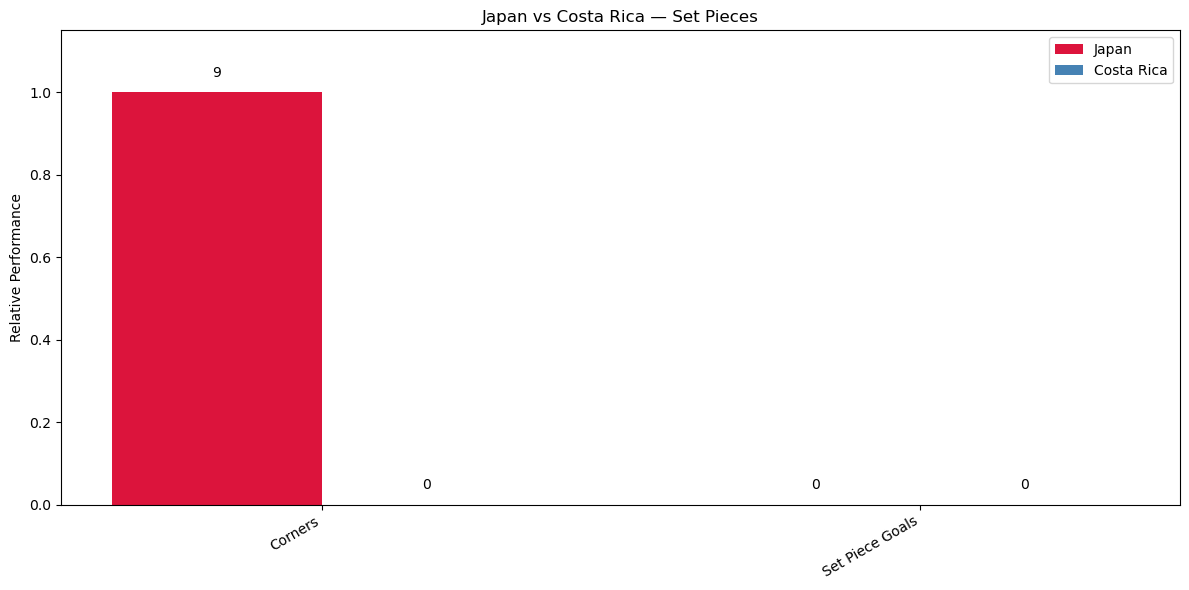

In [75]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Japan Women's") &
        (womens_world_cup_stats["opponent"] == "Costa Rica Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Costa Rica Women's") &
        (womens_world_cup_stats["opponent"] == "Japan Women's")
    )
].copy()

# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses"
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "Japan": "Japan Women's",
    "Costa Rica": "Costa Rica Women's"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    jap_values = np.array([
        match.loc[
            match["team"] == team_names["Japan"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    crc_values = np.array([
        match.loc[
            match["team"] == team_names["Costa Rica"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(jap_values, crc_values)

    # Normalize
    jap_normalized = np.divide(
        jap_values,
        max_values,
        out=np.zeros_like(jap_values),
        where=max_values != 0
    )

    crc_normalized = np.divide(
        crc_values,
        max_values,
        out=np.zeros_like(crc_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_jap = plt.bar(
        x - width / 2,
        jap_normalized,
        width,
        label="Japan",
        color="crimson"
    )

    bars_crc = plt.bar(
        x + width / 2,
        crc_normalized,
        width,
        label="Costa Rica",
        color="steelblue"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_jap, jap_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_crc, crc_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"Japan vs Costa Rica — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

## Conclusion JAP-CRC

Japan dominated the game on offense. The *Chance Creation* chart showed very high numbers for the Asian team. However, on defense, Costa Rica kept pace with Japan, saving **9 shots on goal** out of a total of 11. 
They also led in blocks with 16 and clearances with 36.
Although they completed fewer passes than Japan, their passing accuracy was quite good (76.8%).
Despite the result, Costa Rica’s performance and efficiency against Japan’s highly offensive strategy were highly positive.

# Analysis Spain's Group Stage games

In [81]:
team = "Spain Women's"

games = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == team) |
        (womens_world_cup_stats["opponent"] == team)
    )
    &
    (womens_world_cup_stats["stage"] == "Group")
]

games[["match_id", "team", "opponent", "stage"]]

,match_id,team,opponent,stage
8,3893791,Costa Rica Women's,Spain Women's,Group
9,3893791,Spain Women's,Costa Rica Women's,Group
38,3893806,Spain Women's,Zambia W,Group
39,3893806,Zambia W,Spain Women's,Group
70,3893822,Japan Women's,Spain Women's,Group
71,3893822,Spain Women's,Japan Women's,Group


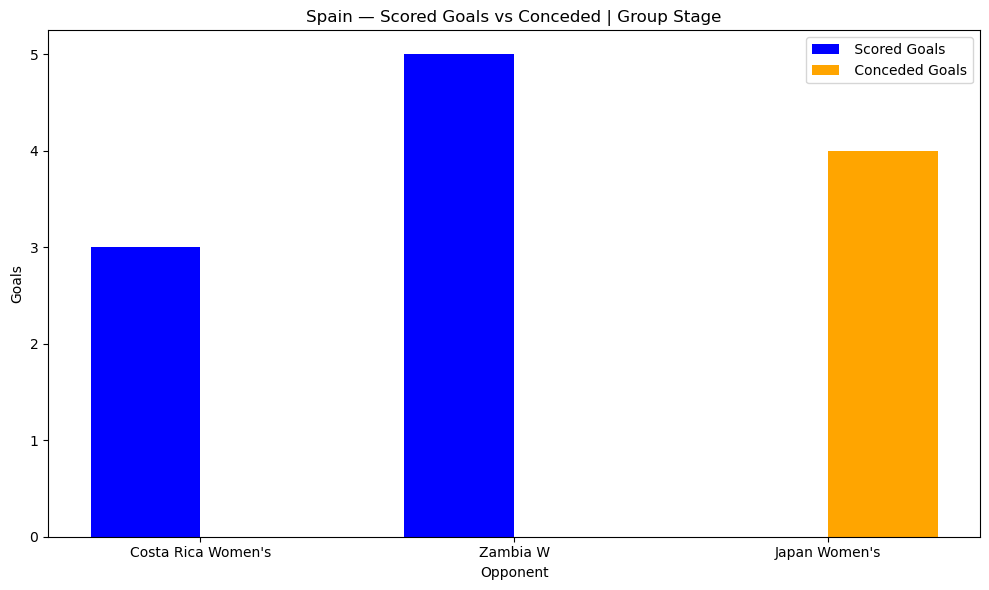

In [85]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Spain Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["goals_for"],
    width,
    label=" Scored Goals",
    color = "blue"
)

plt.bar(
    x + width / 2,
    group_games["goals_against"],
    width,
    label= " Conceded Goals",
    color = "orange"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Spain — Scored Goals vs Conceded | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

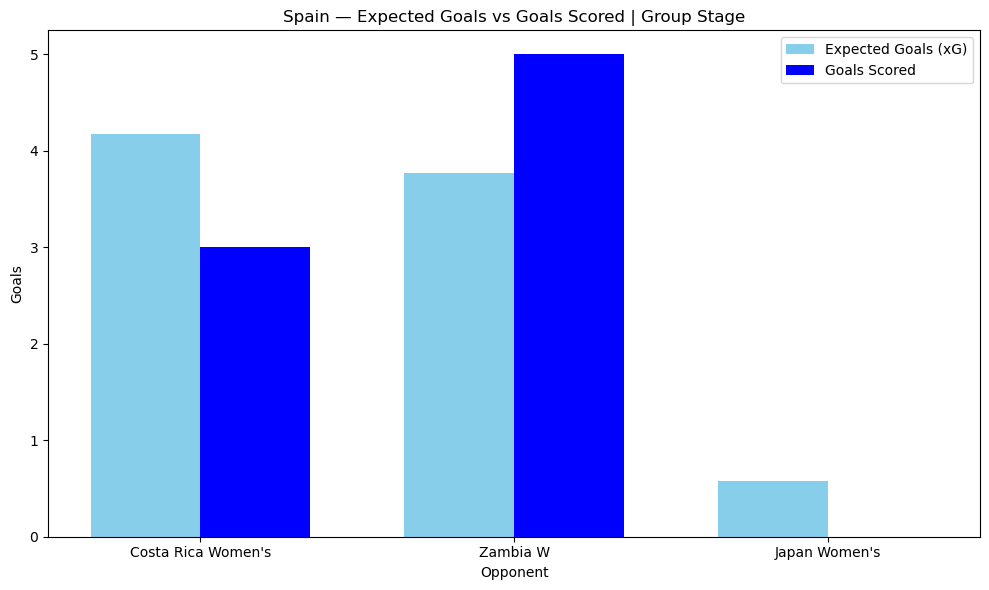

In [87]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Spain Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    group_games["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Spain — Expected Goals vs Goals Scored | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

In all three of its group-stage matches, the Spanish national team scored fewer goals than expected, except in the game against Zambia. The biggest discrepancy was in the game against Costa Rica.  

# Analysis of SPA-ZAM

In [90]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Spain Women's") &
        (womens_world_cup_stats["opponent"] == "Zambia W")
    ) |
    (
        (womens_world_cup_stats["team"] == "Zambia W") &
        (womens_world_cup_stats["opponent"] == "Spain Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "Spain": [
        match.loc[
            match["team"] == "Spain Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Zambia": [
        match.loc[
            match["team"] == "Zambia W", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Spain", "Zambia"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Spain", "Zambia"]
].round(1)


# Display table

comparison

,Metric,Spain,Zambia
0,Goals,5.0,0.0
1,xG,3.8,0.4
2,Goals Minus xG,1.2,-0.4
3,Shots,22.0,10.0
4,Shots on Target,12.0,2.0
5,Saves,2.0,8.0
6,Possession %,68.8,31.2
7,Pass Accuracy %,85.6,58.4
8,Progressive Passes,180.0,83.0
9,Progressive Carries,29.0,14.0


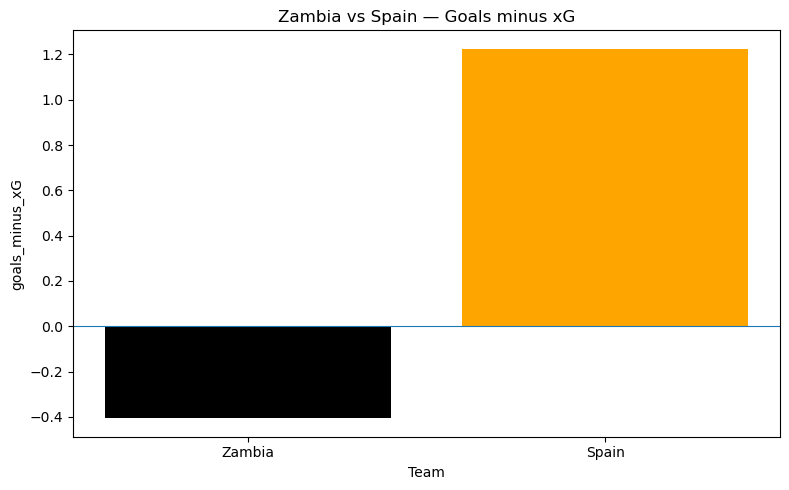

In [93]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Spain Women's") &
        (womens_world_cup_stats["opponent"] == "Zambia W")
    ) |
    (
        (womens_world_cup_stats["team"] == "Zambia W") &
        (womens_world_cup_stats["opponent"] == "Spain Women's")
    )
].copy()


teams = ["Zambia", "Spain"]

goals_minus_xG = [
    match.loc[match["team"] == "Zambia W", "goals_minus_xG"].iloc[0],
    match.loc[match["team"] == "Spain Women's", "goals_minus_xG"].iloc[0]
]

plt.figure(figsize=(8, 5))

plt.bar(
    teams,
    goals_minus_xG,
    color=["black", "orange"]
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Team")
plt.ylabel("goals_minus_xG")
plt.title("Zambia vs Spain — Goals minus xG")

plt.tight_layout()
plt.show()

Spain outperformed expectations with 1.2 xG minus Goals, and Zambia with -0.4. 

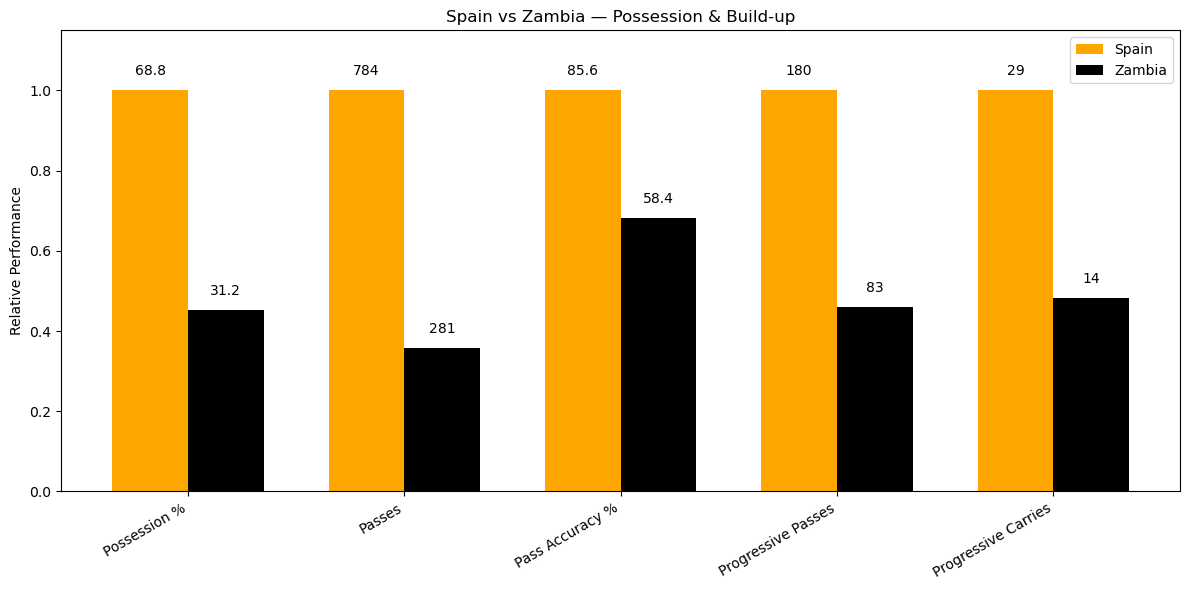

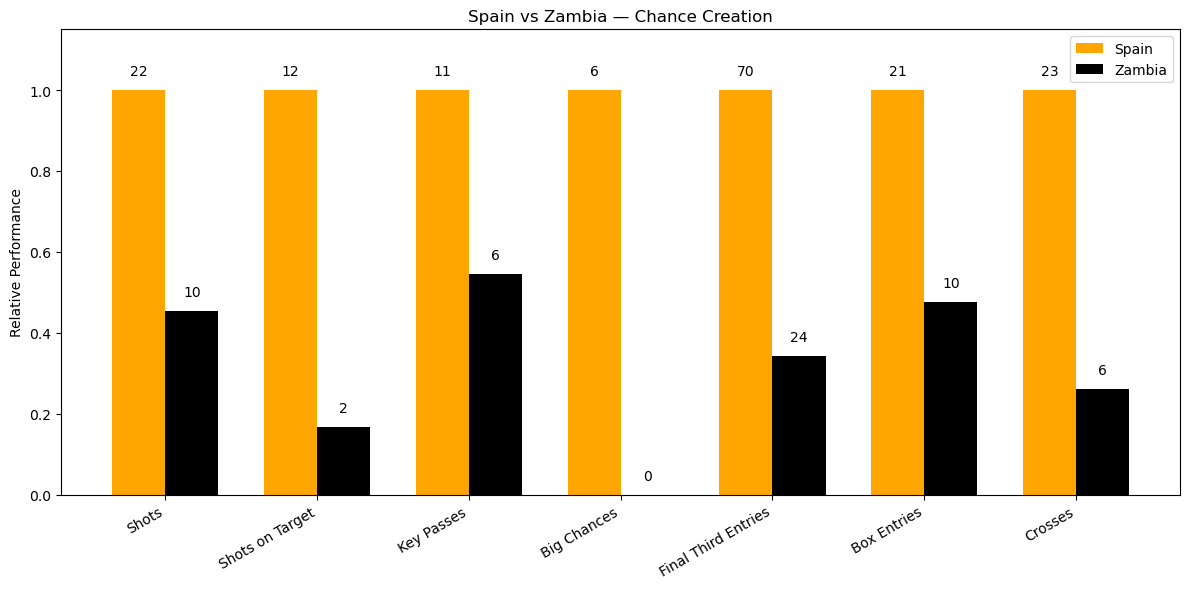

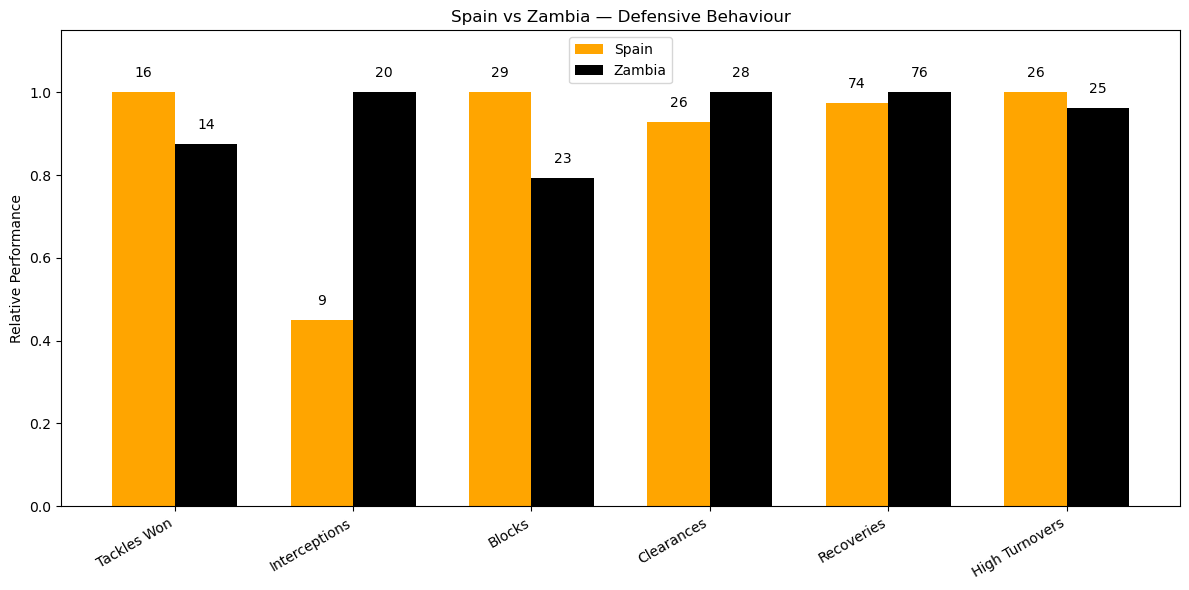

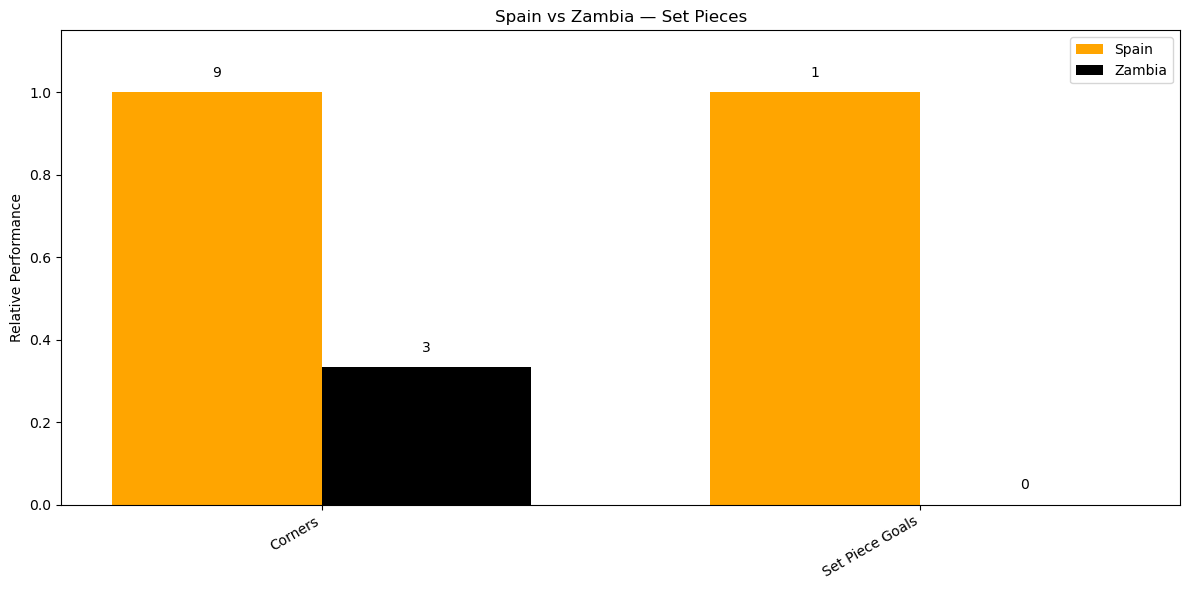

In [96]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Spain Women's") &
        (womens_world_cup_stats["opponent"] == "Zambia W")
    ) |
    (
        (womens_world_cup_stats["team"] == "Zambia W") &
        (womens_world_cup_stats["opponent"] == "Spain Women's")
    )
].copy()

# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses"
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "Spain": "Spain Women's",
    "Zambia": "Zambia W"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    spa_values = np.array([
        match.loc[
            match["team"] == team_names["Spain"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    zam_values = np.array([
        match.loc[
            match["team"] == team_names["Zambia"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(spa_values, zam_values)

    # Normalize
    spa_normalized = np.divide(
        spa_values,
        max_values,
        out=np.zeros_like(spa_values),
        where=max_values != 0
    )

    zam_normalized = np.divide(
        zam_values,
        max_values,
        out=np.zeros_like(zam_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_spa = plt.bar(
        x - width / 2,
        spa_normalized,
        width,
        label="Spain",
        color="orange"
    )

    bars_zam = plt.bar(
        x + width / 2,
        zam_normalized,
        width,
        label="Zambia",
        color="black"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_spa, spa_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_zam, zam_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"Spain vs Zambia — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

## Conclusion of SPA-ZAM

The Spanish national team dominated the entire game against the African team. <br>
In all statistical categories, La Roja almost always outnumbered Zambia. <br>
However, it is worth noting that, despite being considered an inferior opponent, Zambia did not give up and maintained a defensive stance, saving 8 of the shots on goal and keeping a cohesive defense (as seen in the metrics for interceptions, clearances, and recoveries).

# Analysis of SPA-CRC

In [102]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Spain Women's") &
        (womens_world_cup_stats["opponent"] == "Costa Rica Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Costa Rica Women's") &
        (womens_world_cup_stats["opponent"] == "Spain Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "Spain": [
        match.loc[
            match["team"] == "Spain Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Costa Rica": [
        match.loc[
            match["team"] == "Costa Rica Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Spain", "Costa Rica"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Spain", "Costa Rica"]
].round(1)


# Display table

comparison

,Metric,Spain,Costa Rica
0,Goals,3.0,0.0
1,xG,4.2,0.1
2,Goals Minus xG,-2.2,-0.1
3,Shots,46.0,1.0
4,Shots on Target,12.0,0.0
5,Saves,0.0,10.0
6,Possession %,83.8,16.2
7,Pass Accuracy %,84.1,48.0
8,Progressive Passes,133.0,54.0
9,Progressive Carries,26.0,7.0


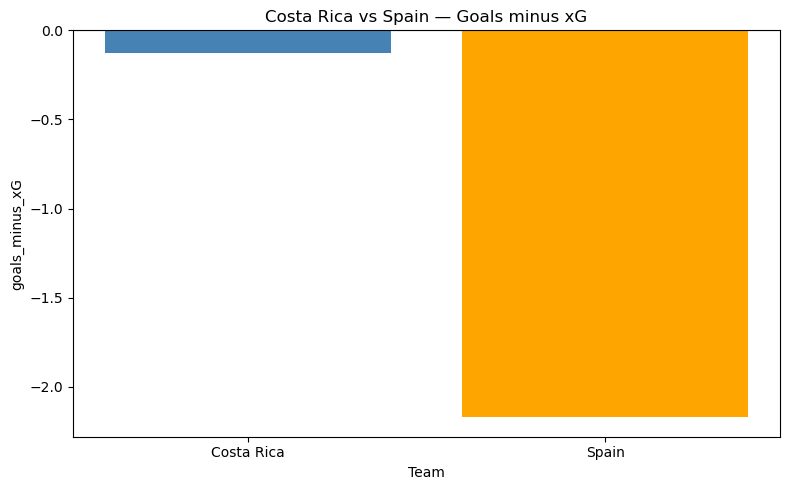

In [104]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Spain Women's") &
        (womens_world_cup_stats["opponent"] == "Costa Rica Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Costa Rica Women's") &
        (womens_world_cup_stats["opponent"] == "Spain Women's")
    )
].copy()



teams = ["Costa Rica", "Spain"]

goals_minus_xG = [
    match.loc[match["team"] == "Costa Rica Women's", "goals_minus_xG"].iloc[0],
    match.loc[match["team"] == "Spain Women's", "goals_minus_xG"].iloc[0]
]

plt.figure(figsize=(8, 5))

plt.bar(
    teams,
    goals_minus_xG,
    color=["steelblue", "orange"]
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Team")
plt.ylabel("goals_minus_xG")
plt.title("Costa Rica vs Spain — Goals minus xG")

plt.tight_layout()
plt.show()

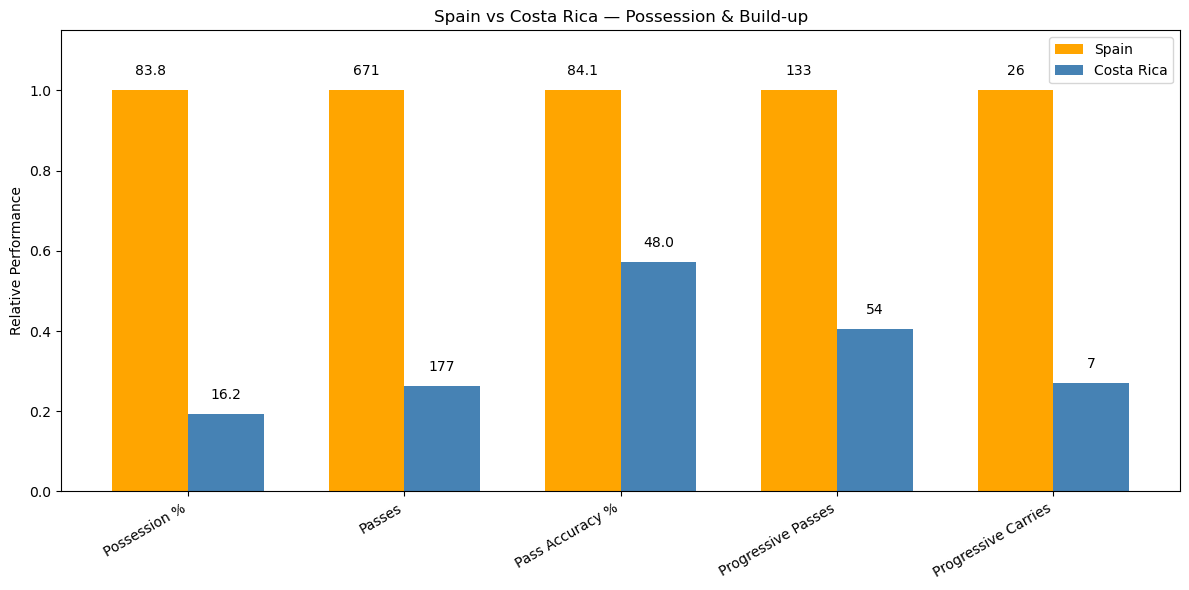

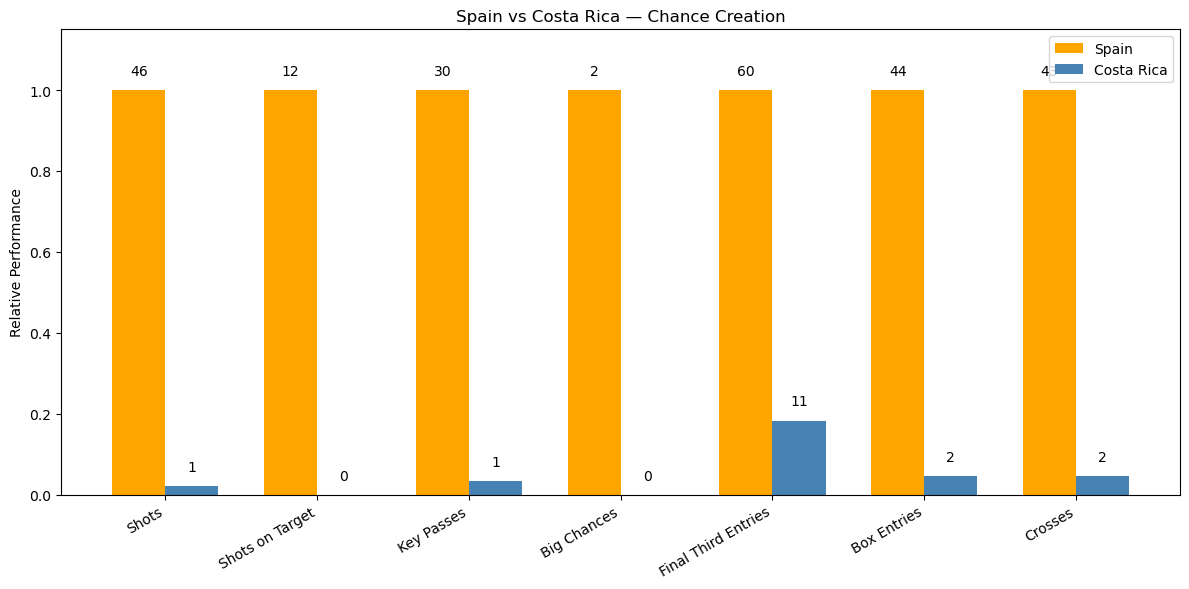

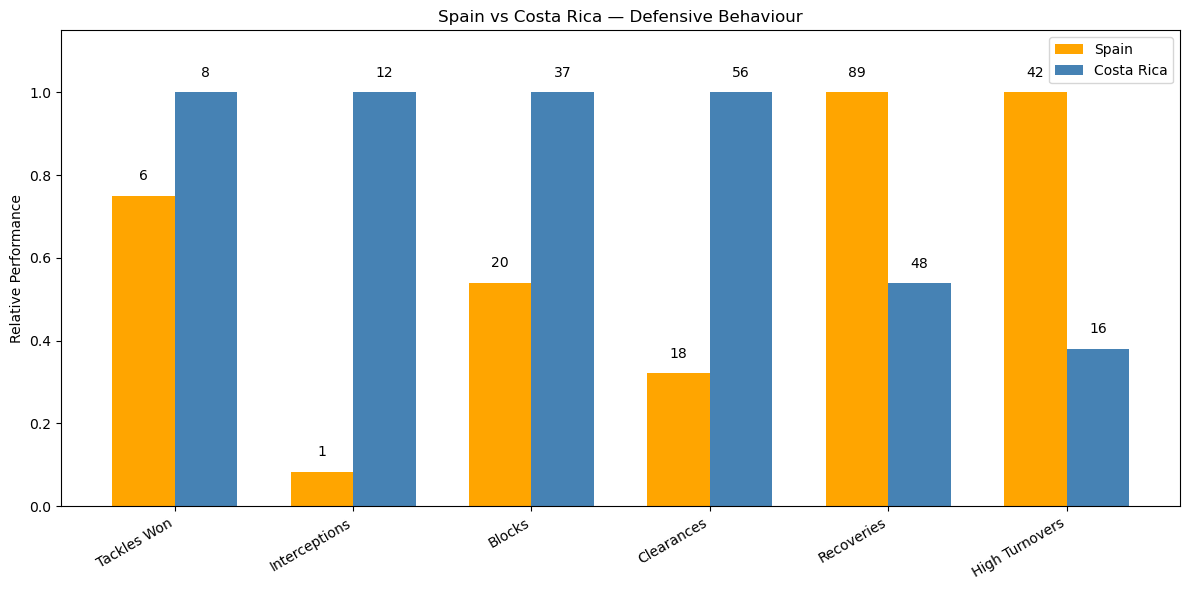

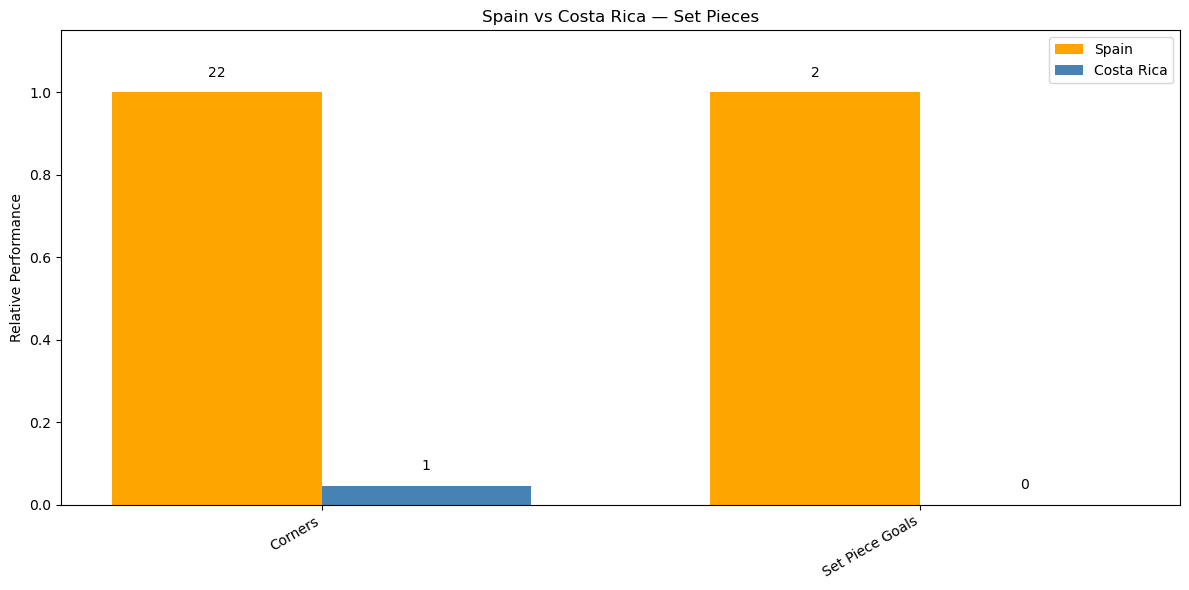

In [106]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Spain Women's") &
        (womens_world_cup_stats["opponent"] == "Costa Rica Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Costa Rica Women's") &
        (womens_world_cup_stats["opponent"] == "Spain Women's")
    )
].copy()

# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses"
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "Spain": "Spain Women's",
    "Costa Rica": "Costa Rica Women's"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    spa_values = np.array([
        match.loc[
            match["team"] == team_names["Spain"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    crc_values = np.array([
        match.loc[
            match["team"] == team_names["Costa Rica"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(spa_values, crc_values)

    # Normalize
    spa_normalized = np.divide(
        spa_values,
        max_values,
        out=np.zeros_like(spa_values),
        where=max_values != 0
    )

    crc_normalized = np.divide(
        crc_values,
        max_values,
        out=np.zeros_like(crc_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_spa = plt.bar(
        x - width / 2,
        spa_normalized,
        width,
        label="Spain",
        color="orange"
    )

    bars_crc = plt.bar(
        x + width / 2,
        crc_normalized,
        width,
        label="Costa Rica",
        color="steelblue"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_spa, spa_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_crc, crc_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"Spain vs Costa Rica — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

## Conclusion of SPA - ZAM

Spain’s dominance in the match against Costa Rica was overwhelming; however, after analyzing the statistics, I concluded that Spain squandered quite a few opportunities. Let’s take a look:
- shots: 46 - 1
- shots on target: 12 - 0
- big chances: 1 - 0 
- saves: 0 - 10

Of **46 shots**, only **12** were on target. And of those 12, there were **10** saves (here I give credit to Zambia, of course). This means that 34 shots were wasted. 

Despite their remarkable dominance, Spain lacked the finishing touch.

# Analysis Zambia's Group Stage games

In [113]:
team = "Zambia W"

games = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == team) |
        (womens_world_cup_stats["opponent"] == team)
    )
    &
    (womens_world_cup_stats["stage"] == "Group")
]

games[["match_id", "team", "opponent", "stage"]]

,match_id,team,opponent,stage
12,3893793,Japan Women's,Zambia W,Group
13,3893793,Zambia W,Japan Women's,Group
38,3893806,Spain Women's,Zambia W,Group
39,3893806,Zambia W,Spain Women's,Group
72,3893823,Costa Rica Women's,Zambia W,Group
73,3893823,Zambia W,Costa Rica Women's,Group


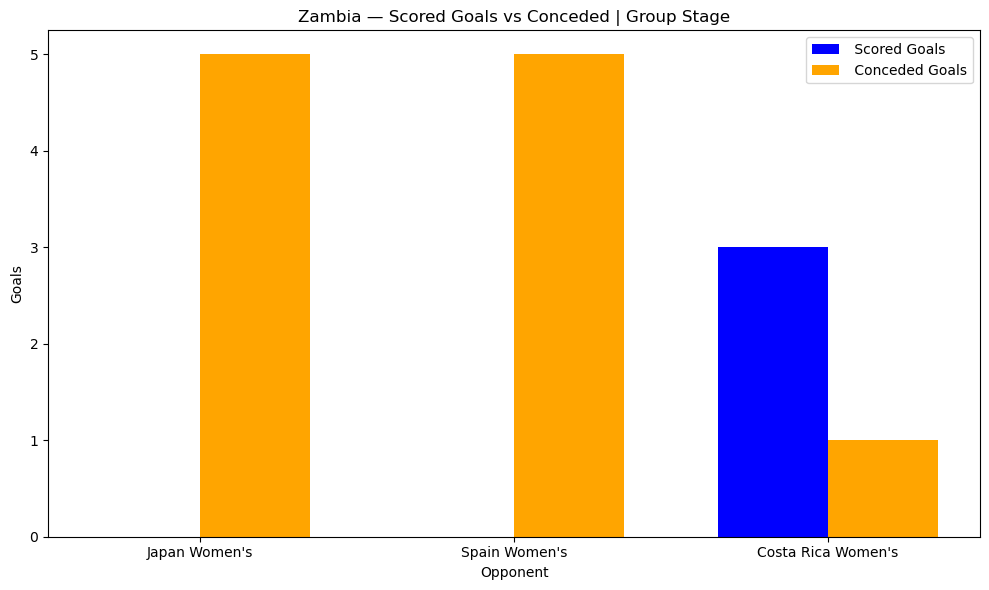

In [115]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Zambia W") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["goals_for"],
    width,
    label=" Scored Goals",
    color = "blue"
)

plt.bar(
    x + width / 2,
    group_games["goals_against"],
    width,
    label= " Conceded Goals",
    color = "orange"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Zambia — Scored Goals vs Conceded | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

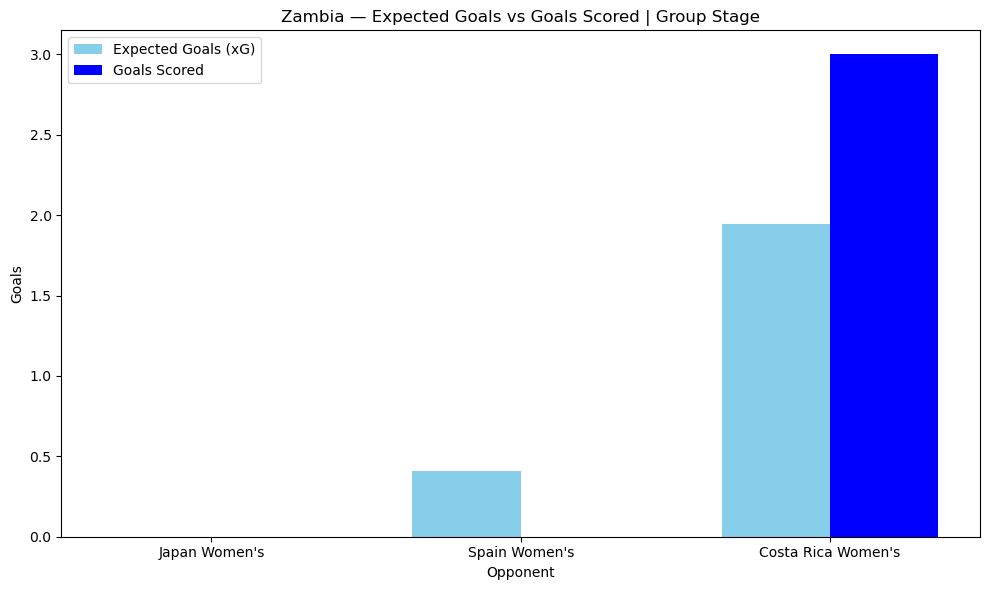

In [117]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Zambia W") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    group_games["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Zambia — Expected Goals vs Goals Scored | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

Zambia’s numbers are somewhat volatile. In the three games played, it seems that Zambia aligns with the statistics—that is, the stronger the data suggests the team is, the lower the xG assigned to it. And it delivers. <br>
<br>
0.0–0.0 against Japan
<br>
0.4–0.0 against Spain 
<br>
1.8–3.0 against Costa Rica

What could be considered an outlier is Spain, which did not score any goals.

# Analysis of ZAM-CRC

In [127]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Zambia W") &
        (womens_world_cup_stats["opponent"] == "Costa Rica Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Costa Rica Women's") &
        (womens_world_cup_stats["opponent"] == "Zambia W")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "Zambia": [
        match.loc[
            match["team"] == "Zambia W", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Costa Rica": [
        match.loc[
            match["team"] == "Costa Rica Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Zambia", "Costa Rica"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Zambia", "Costa Rica"]
].round(1)


# Display table

comparison

,Metric,Zambia,Costa Rica
0,Goals,3.0,1.0
1,xG,1.9,2.3
2,Goals Minus xG,1.1,-1.3
3,Shots,15.0,16.0
4,Shots on Target,8.0,3.0
5,Saves,2.0,5.0
6,Possession %,44.8,55.2
7,Pass Accuracy %,60.9,74.0
8,Progressive Passes,79.0,95.0
9,Progressive Carries,20.0,27.0


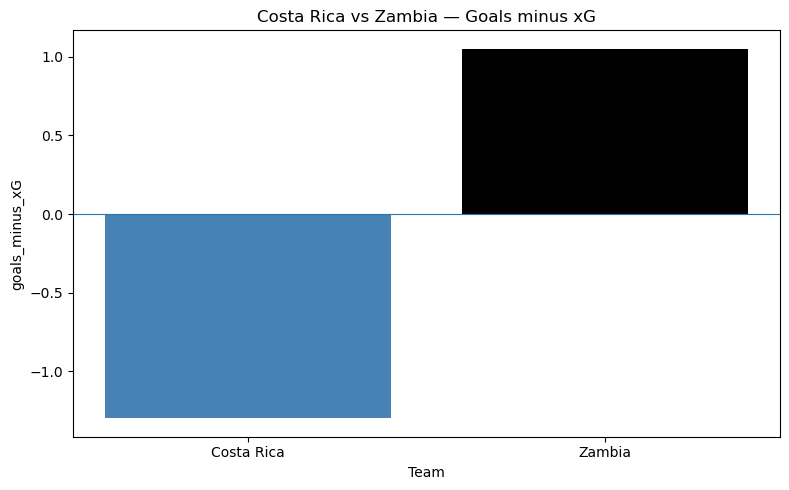

In [138]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Zambia W") &
        (womens_world_cup_stats["opponent"] == "Costa Rica Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Costa Rica Women's") &
        (womens_world_cup_stats["opponent"] == "Zambia W")
    )
].copy()



teams = ["Costa Rica", "Zambia"]

goals_minus_xG = [
    match.loc[match["team"] == "Costa Rica Women's", "goals_minus_xG"].iloc[0],
    match.loc[match["team"] == "Zambia W", "goals_minus_xG"].iloc[0]
]

plt.figure(figsize=(8, 5))

plt.bar(
    teams,
    goals_minus_xG,
    color=["steelblue", "black"]
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Team")
plt.ylabel("goals_minus_xG")
plt.title("Costa Rica vs Zambia — Goals minus xG")

plt.tight_layout()
plt.show()

The results in this chart are very interesting because it was expected that Costa Rica would score more goals, but the opposite happened. <br> After a quick look at the table above, I could see that it was a closely contested game, but let’s take a closer look.

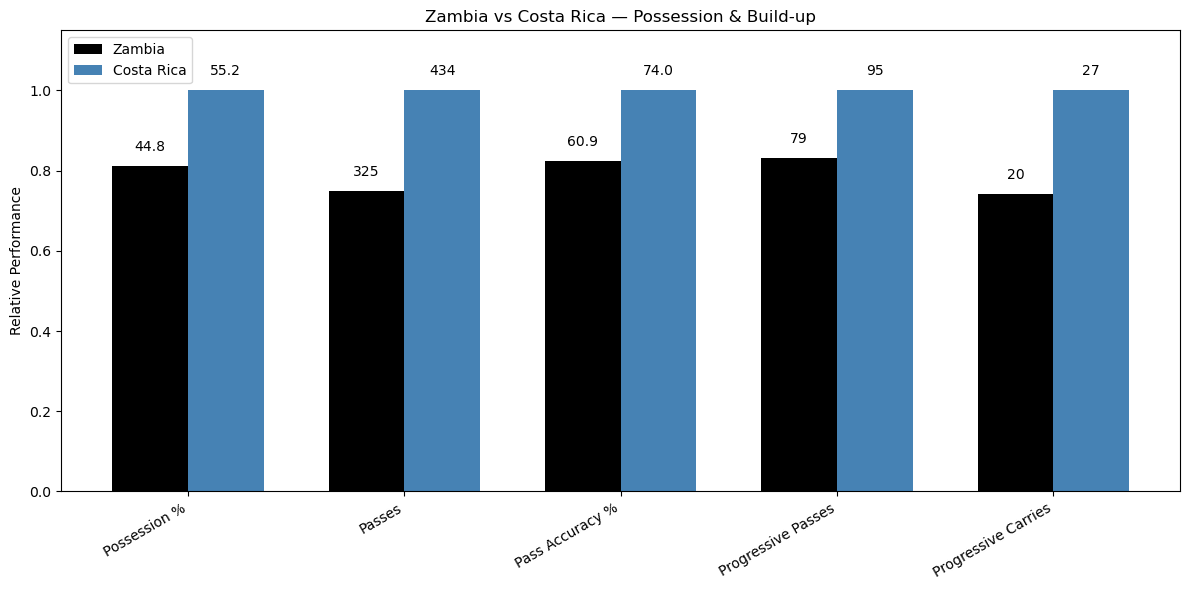

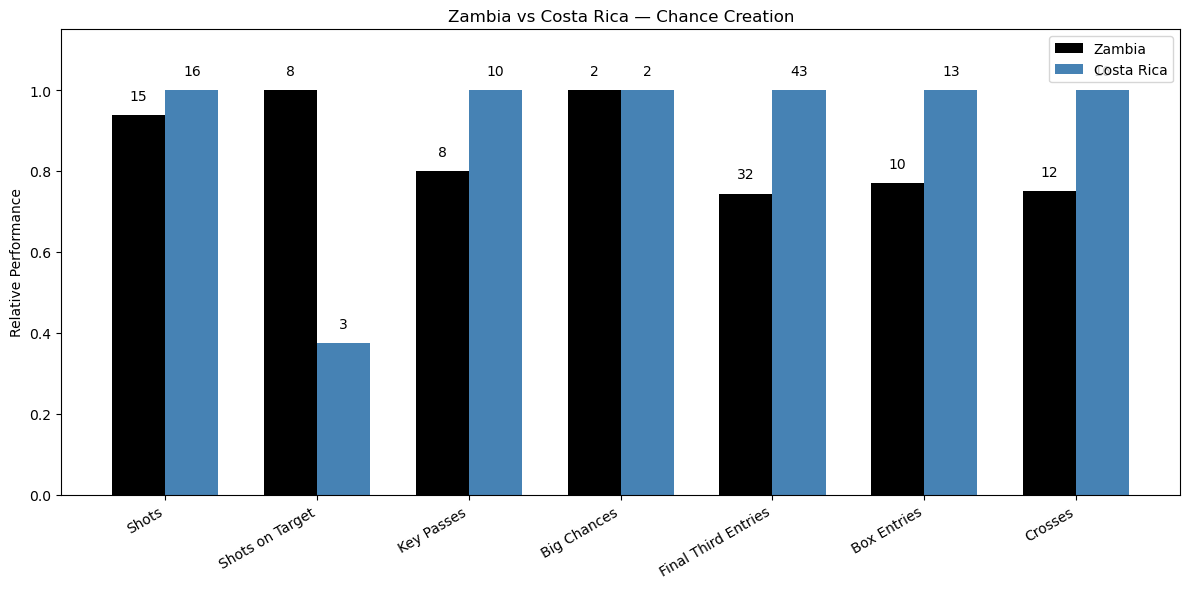

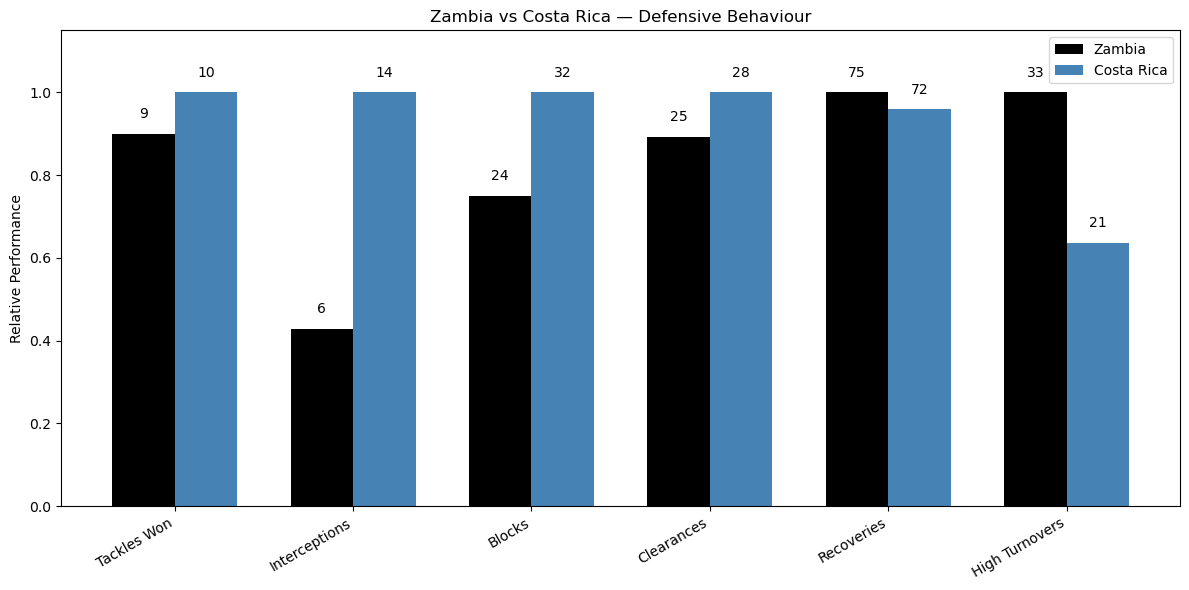

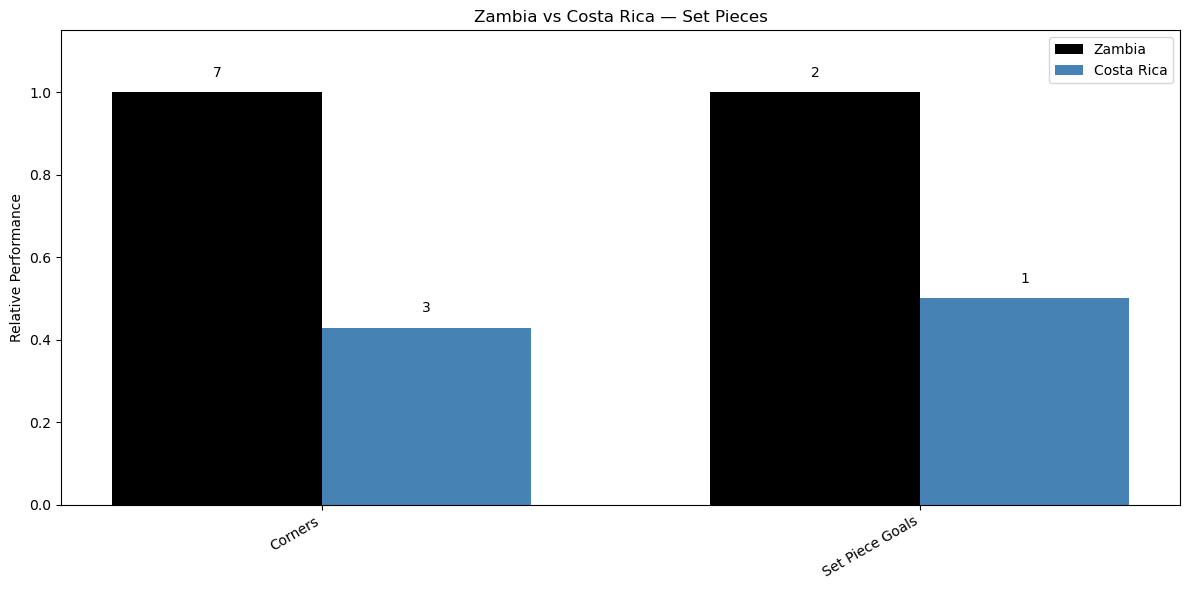

In [141]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Zambia W") &
        (womens_world_cup_stats["opponent"] == "Costa Rica Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Costa Rica Women's") &
        (womens_world_cup_stats["opponent"] == "Zambia W")
    )
].copy()

# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses"
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "Zambia": "Zambia W",
    "Costa Rica": "Costa Rica Women's"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    zam_values = np.array([
        match.loc[
            match["team"] == team_names["Zambia"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    crc_values = np.array([
        match.loc[
            match["team"] == team_names["Costa Rica"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(zam_values, crc_values)

    # Normalize
    zam_normalized = np.divide(
        zam_values,
        max_values,
        out=np.zeros_like(zam_values),
        where=max_values != 0
    )

    crc_normalized = np.divide(
        crc_values,
        max_values,
        out=np.zeros_like(crc_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_zam = plt.bar(
        x - width / 2,
        zam_normalized,
        width,
        label="Zambia",
        color="black"
    )

    bars_crc = plt.bar(
        x + width / 2,
        crc_normalized,
        width,
        label="Costa Rica",
        color="steelblue"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_zam, zam_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_crc, crc_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"Zambia vs Costa Rica — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()


## Conclusion ZAM-CRC

It was a very evenly matched game in which, at first glance, one might say that Costa Rica had the upper hand. However, Zambia was far more productive and efficient in terms of its strategy. <br>
<br> Both defensive and chance-creation metrics look quite positive when compared side by side.

# Final Conclusion Group C

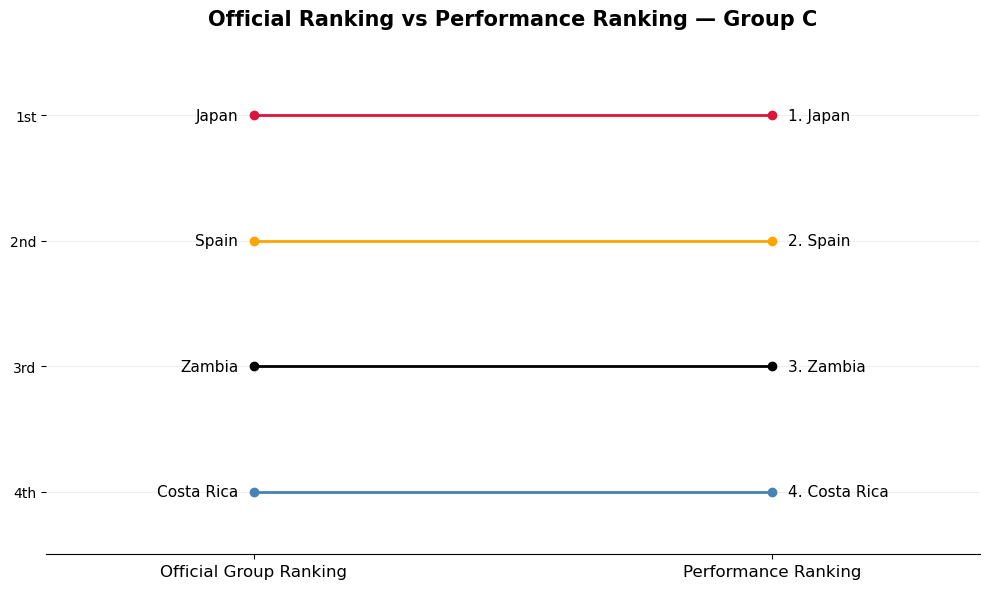

In [148]:
import matplotlib.pyplot as plt
import pandas as pd

# ==========================================
# DATA
# ==========================================

ranking = pd.DataFrame({
    "team": ["Japan", "Spain", "Zambia", "Costa Rica"],
    "official_rank": [1, 2, 3, 4],
    "performance_rank": [1, 2, 3, 4]
})

# ==========================================
# COLORS
# ==========================================

team_colors = {
    "Japan": "crimson",
    "Spain": "orange",
    "Zambia": "black",
    "Costa Rica": "Steelblue"
}

# ==========================================
# PLOT
# ==========================================

fig, ax = plt.subplots(figsize=(10, 6))

for _, row in ranking.iterrows():

    ax.plot(
        [0, 1],
        [row["official_rank"], row["performance_rank"]],
        marker="o",
        linewidth=2,
        color=team_colors[row["team"]]
    )

    # Official ranking
    ax.text(
        -0.03,
        row["official_rank"],
        row["team"],
        ha="right",
        va="center",
        fontsize=11
    )

    # Performance ranking
    ax.text(
        1.03,
        row["performance_rank"],
        f'{row["performance_rank"]}. {row["team"]}',
        ha="left",
        va="center",
        fontsize=11
    )

# ==========================================
# FORMATTING
# ==========================================

ax.set_xlim(-0.4, 1.4)
ax.set_ylim(4.5, 0.5)

ax.set_xticks([0, 1])
ax.set_xticklabels([
    "Official Group Ranking",
    "Performance Ranking"
], fontsize=12)

ax.set_yticks([1, 2, 3, 4])
ax.set_yticklabels(["1st", "2nd", "3rd", "4th"])

ax.set_title(
    "Official Ranking vs Performance Ranking — Group C",
    fontsize=15,
    fontweight="bold",
    pad=20
)

ax.grid(axis="y", alpha=0.2)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

In the performance-based rankings, I’d highlight Japan and Spain as the undisputed 1st and 2nd place finishers. <br>
<br> 
Japan had three wins, with overwhelming performances such as in the game against Spain. As for La Roja, despite their loss to the Asian team, they proved that their second-place finish is well-deserved through their outstanding performances in the matches against Zambia and Costa Rica. <br>
<br>
However, I’d like to highlight Zambia’s strategy of adapting to stronger opponents by adopting a more defensive approach. Yet, once the team was within striking distance, it defied all expectations and stood out by scoring more goals. Zambia is in third place, but very close to Spain.